# Reading, plotting and animating data from EUMETSAT using satpy

Use satpy package to read EUMETSAT data
https://satpy.readthedocs.io/en/latest/index.html

Satpy does not provide an interface to *download* satellite data, it assumes that the data is on a *local* disk already.

Quickstart with MSG data : https://nbviewer.org/github/pytroll/pytroll-examples/blob/main/satpy/hrit_msg_tutorial.ipynb

## Loading data
Loading the data is done on-the-fly with satpy when a composite is to be generated. So first we create a scene instance, pointing the base_dir directory to the place containing the uncompressed .nat data files.

Scene class:
https://satpy.readthedocs.io/en/latest/api/satpy.scene.html#satpy.scene.Scene

To get a list of available composites or datasets to choose from:

scn.available_composite_ids()

scn.available_dataset_ids()

['HRV', 'IR_016', 'IR_039', 'IR_087', 'IR_097', 'IR_108', 'IR_120', 'IR_134', 'VIS006', 'VIS008', 'WV_062', 'WV_073']
['24h_microphysics', 'airmass', 'ash', 'cloud_phase_distinction', 'cloud_phase_distinction_raw', 'cloudtop', 'cloudtop_daytime', 'colorized_ir_clouds', 'convection', 'day_microphysics', 'day_microphysics_winter', 'day_severe_storms', 'day_severe_storms_tropical', 'dust', 'fog', 'green_snow', 'hrv_clouds', 'hrv_fog', 'hrv_severe_storms', 'hrv_severe_storms_masked', 'ir108_3d', 'ir_cloud_day', 'ir_overview', 'ir_sandwich', 'natural_color', 'natural_color_nocorr', 'natural_color_raw', 'natural_color_raw_with_night_ir', 'natural_color_with_night_ir', 'natural_color_with_night_ir_hires', 'natural_enh', 'natural_enh_with_night_ir', 'natural_enh_with_night_ir_hires', 'natural_with_night_fog', 'night_fog', 'night_ir_alpha', 'night_ir_with_background', 'night_ir_with_background_hires', 'night_microphysics', 'night_microphysics_tropical', 'overshooting_tops', 'overview', 'overvie

INFO:satpy.resample.base:Using default KDTree resampler
INFO:satpy.writers.cf_writer:Saving datasets to NetCDF4/CF.


<xarray.DataArray 'my_index-b34c38241e04ab9ed11775a541a5b3fd' (y: 375, x: 275)> Size: 412kB
dask.array<my_index, shape=(375, 275), dtype=float32, chunksize=(375, 275), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 3kB -30.02 -30.06 -30.1 -30.14 ... -44.9 -44.94 -44.98
  * x        (x) float64 2kB 10.02 10.06 10.1 10.14 ... 20.86 20.9 20.94 20.98
    crs      object 8B GEOGCRS["unknown",DATUM["World Geodetic System 1984",E...
Attributes: (12/18)
    orbital_parameters:       {'projection_longitude': np.float32(0.0), 'proj...
    units:                    K
    wavelength:               10.8 µm (9.8-11.8 µm)
    standard_name:            toa_brightness_temperature
    platform_name:            Meteosat-10
    sensor:                   seviri
    ...                       ...
    name:                     IR_108
    resolution:               3000.403165817
    calibration:              brightness_temperature
    modifiers:                ()
    _satpy_id:                D

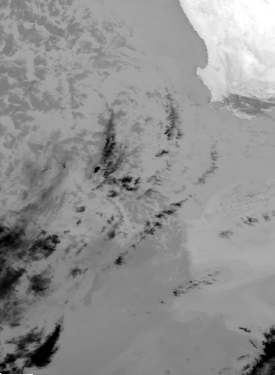

In [91]:
from satpy import Scene
from pyresample import create_area_def

dataset_id = 'IR_108'
composite_id = 'ir_overview'
calibration_id = 'brightness_temperature'

lon_min, lon_max = 10.0, 21.0
lat_min, lat_max = -45.0, -30.0

fn = "/Users/luciereymondet/Documents/EUMETSAT_GOFLOW/MSG3-SEVI-MSG15-0100-NA-20230330121241.373000000Z-NA/MSG3-SEVI-MSG15-0100-NA-20230330121241.373000000Z-NA.nat"
scn = Scene(filenames=[fn], reader="seviri_l1b_native")
print(scn.available_dataset_names())
print(scn.available_composite_names())

scn.load([dataset_id], calibration=calibration_id)
local_scn = scn.crop(ll_bbox=(lon_min, lat_min, lon_max, lat_max))

area_def = create_area_def(
    area_id='geographic_area', # sets the name for the CF grid_mapping variable.
    
    description = 'Region overlapping the SWOT AdAC QUICCHE campaign', # optional

    projection = {'proj': 'latlong', 'datum': 'WGS84'}, # equivalently projection = 'EPSG:4326'. Parameterizes the CF grid_mapping variable.
    
    # width=250, height=250,        # number of pixels in the x and y directions, depending on desired resolution
    resolution = (0.04, 0.04),    # or specify a pixel size (in projection units) e.g. 0.05 degrees per pixel
    # shape = (250, 250)          # or tuple (height, width)

    area_extent=(lon_min, lat_min, lon_max, lat_max) # bounding box in projection coordinates, units are implied through projection argument
)

resampled_scn = local_scn.resample(area_def)

print(resampled_scn)
# Save the resampled dataset to NetCDF
resampled_scn.save_datasets(
    writer='cf',                   # CF-compliant NetCDF writer
    datasets=['IR_108'],           # which dataset(s) to save
    filename='IR_108_bt_geo.nc',   # output file name
)

resampled_scn.show('IR_108')

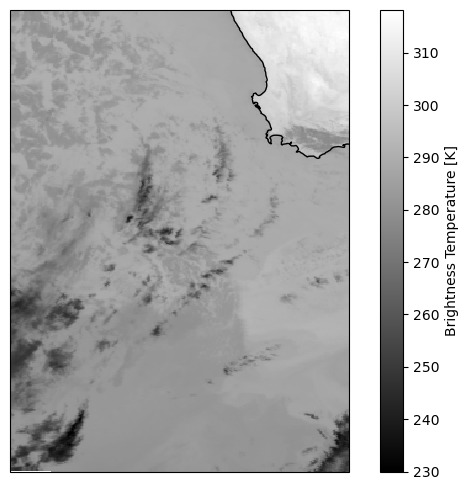

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

da = xr.open_dataset("IR_108_bt_geo.nc")['IR_108']


fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(da.longitude, da.latitude, da, cmap='gray', transform=ccrs.PlateCarree())
ax.coastlines()
plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')
plt.show()
